In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import files

uploaded = files.upload()
uploaded_names = list(uploaded.keys())

planned_file = next(
    name for name in uploaded_names
    if "planned_bim_integrated" in name.lower()
)

asbuilt_file = next(
    name for name in uploaded_names
    if "asbuilt_bim_integrated" in name.lower()
)

planned = pd.read_csv(planned_file)
asbuilt = pd.read_csv(asbuilt_file)

print("Planned integrated:", planned.shape)
print("As-built integrated:", asbuilt.shape)

Saving asbuilt_bim_integrated.csv to asbuilt_bim_integrated.csv
Saving planned_bim_integrated.csv to planned_bim_integrated.csv
Planned integrated: (7166, 24)
As-built integrated: (3661, 25)


In [2]:
for dataframe in [planned, asbuilt]:

    dataframe["TaskStart"] = pd.to_datetime(
        dataframe["TaskStart"],
        errors="coerce"
    )

    dataframe["TaskFinish"] = pd.to_datetime(
        dataframe["TaskFinish"],
        errors="coerce"
    )

asbuilt["LateFlag"] = (
    asbuilt["Element on time or not"]
    == "Too late"
).astype(int)

print(
    asbuilt["Element on time or not"]
    .value_counts()
)

Element on time or not
On time     3467
Too late     194
Name: count, dtype: int64


In [3]:
total_planned_records = len(planned)
observed_records = len(asbuilt)

planned_elements = planned["GUID"].nunique()
observed_elements = asbuilt["GUID"].nunique()

late_records = asbuilt["LateFlag"].sum()

late_elements = asbuilt.loc[
    asbuilt["LateFlag"] == 1,
    "GUID"
].nunique()

record_coverage = (
    observed_records / total_planned_records * 100
)

element_coverage = (
    observed_elements / planned_elements * 100
)

late_record_rate = (
    late_records / observed_records * 100
)

late_element_rate = (
    late_elements / observed_elements * 100
)

overall_metrics = pd.DataFrame({
    "Metric": [
        "Planned element-task records",
        "Observed element-task records",
        "Planned unique BIM elements",
        "Observed unique BIM elements",
        "Late element-task records",
        "Unique BIM elements affected by delay",
        "Record coverage (%)",
        "Element coverage (%)",
        "Late-record rate (%)",
        "Observed-element delay rate (%)"
    ],
    "Value": [
        total_planned_records,
        observed_records,
        planned_elements,
        observed_elements,
        late_records,
        late_elements,
        round(record_coverage, 2),
        round(element_coverage, 2),
        round(late_record_rate, 2),
        round(late_element_rate, 2)
    ]
})

display(overall_metrics)

,Metric,Value
0,Planned element-task records,7166.00
1,Observed element-task records,3661.00
2,Planned unique BIM elements,3505.00
3,Observed unique BIM elements,2358.00
4,Late element-task records,194.00
5,Unique BIM elements affected by delay,119.00
6,Record coverage (%),51.09
7,Element coverage (%),67.28
8,Late-record rate (%),5.30
9,Observed-element delay rate (%),5.05


In [4]:
task_performance = (
    asbuilt.groupby(
        ["TaskID", "TaskName"],
        dropna=False
    )
    .agg(
        Observed_Records=("GUID", "size"),
        Unique_Elements=("GUID", "nunique"),
        Late_Records=("LateFlag", "sum"),
        Delayed_Elements=(
            "GUID",
            lambda values: values[
                asbuilt.loc[
                    values.index,
                    "LateFlag"
                ] == 1
            ].nunique()
        ),
        Planned_Start=("TaskStart", "min"),
        Planned_Finish=("TaskFinish", "max")
    )
    .reset_index()
)

task_performance["Late_Rate_Percent"] = (
    task_performance["Late_Records"]
    / task_performance["Observed_Records"]
    * 100
).round(2)

task_performance = task_performance.sort_values(
    ["Late_Records", "Late_Rate_Percent"],
    ascending=False
)

display(task_performance.head(15))

,TaskID,TaskName,Observed_Records,Unique_Elements,Late_Records,Delayed_Elements,Planned_Start,Planned_Finish,Late_Rate_Percent
60,ST01060,Metselwerk,527,527,60,60,2015-07-09,2015-07-21,11.39
54,ST00950,Stelwerk buitengevel,171,171,50,50,2015-07-02,2015-07-08,29.24
56,ST00980,Plaatsen kozijnen,171,171,50,50,2015-07-06,2015-07-10,29.24
61,ST01070,Metselwerk,199,199,13,13,2015-07-22,2015-08-04,6.53
58,ST01000,Prefab betonband,84,84,10,10,2015-08-17,2015-08-18,11.90
55,ST00970,Plaatsen kozijnen,176,176,7,7,2015-06-18,2015-06-24,3.98
25,ST00510,Lijmwerk kalkzandsteen elementen,19,19,2,2,2015-06-19,2015-06-23,10.53
63,ST01130,Plaatsen scharnierkap incl. goot en platte daken,313,313,2,2,2015-08-28,2015-09-17,0.64
0,ST00060,Stellen bruggetjes,1,1,0,0,2015-02-26,2015-02-27,0.00
1,ST00070,Nuts invoeren,1,1,0,0,2015-03-02,2015-03-04,0.00


In [5]:
class_performance = (
    asbuilt.groupby(
        "Canonical_IfcClass",
        dropna=False
    )
    .agg(
        Observed_Records=("GUID", "size"),
        Unique_Elements=("GUID", "nunique"),
        Late_Records=("LateFlag", "sum"),
        Delayed_Unique_Elements=(
            "GUID",
            lambda values: values[
                asbuilt.loc[
                    values.index,
                    "LateFlag"
                ] == 1
            ].nunique()
        )
    )
    .reset_index()
)

class_performance["Late_Rate_Percent"] = (
    class_performance["Late_Records"]
    / class_performance["Observed_Records"]
    * 100
).round(2)

class_performance = class_performance.sort_values(
    "Late_Records",
    ascending=False
)

display(class_performance)

,Canonical_IfcClass,Observed_Records,Unique_Elements,Late_Records,Delayed_Unique_Elements,Late_Rate_Percent
12,window,412,259,98,50,23.79
10,wall,789,469,54,44,6.84
4,covering,1015,735,28,15,2.76
5,door,84,66,9,7,10.71
8,slab,560,236,4,2,0.71
11,wallstandardcase,204,115,1,1,0.49
2,buildingelementproxy,14,14,0,0,0.00
1,buildingelementpart,297,265,0,0,0.00
0,beam,252,166,0,0,0.00
3,column,11,11,0,0,0.00


In [6]:
class_performance["Delayed_Element_Rate_Percent"] = (
    class_performance["Delayed_Unique_Elements"]
    / class_performance["Unique_Elements"]
    * 100
).round(2)

class_performance = class_performance.sort_values(
    "Delayed_Element_Rate_Percent",
    ascending=False
)

display(class_performance)

,Canonical_IfcClass,Observed_Records,Unique_Elements,Late_Records,Delayed_Unique_Elements,Late_Rate_Percent,Delayed_Element_Rate_Percent
12,window,412,259,98,50,23.79,19.31
5,door,84,66,9,7,10.71,10.61
10,wall,789,469,54,44,6.84,9.38
4,covering,1015,735,28,15,2.76,2.04
11,wallstandardcase,204,115,1,1,0.49,0.87
8,slab,560,236,4,2,0.71,0.85
2,buildingelementproxy,14,14,0,0,0.00,0.00
1,buildingelementpart,297,265,0,0,0.00,0.00
0,beam,252,166,0,0,0.00,0.00
3,column,11,11,0,0,0.00,0.00


In [7]:
display(task_performance.head(15))

,TaskID,TaskName,Observed_Records,Unique_Elements,Late_Records,Delayed_Elements,Planned_Start,Planned_Finish,Late_Rate_Percent
60,ST01060,Metselwerk,527,527,60,60,2015-07-09,2015-07-21,11.39
54,ST00950,Stelwerk buitengevel,171,171,50,50,2015-07-02,2015-07-08,29.24
56,ST00980,Plaatsen kozijnen,171,171,50,50,2015-07-06,2015-07-10,29.24
61,ST01070,Metselwerk,199,199,13,13,2015-07-22,2015-08-04,6.53
58,ST01000,Prefab betonband,84,84,10,10,2015-08-17,2015-08-18,11.90
55,ST00970,Plaatsen kozijnen,176,176,7,7,2015-06-18,2015-06-24,3.98
25,ST00510,Lijmwerk kalkzandsteen elementen,19,19,2,2,2015-06-19,2015-06-23,10.53
63,ST01130,Plaatsen scharnierkap incl. goot en platte daken,313,313,2,2,2015-08-28,2015-09-17,0.64
0,ST00060,Stellen bruggetjes,1,1,0,0,2015-02-26,2015-02-27,0.00
1,ST00070,Nuts invoeren,1,1,0,0,2015-03-02,2015-03-04,0.00


In [8]:
display(overall_metrics)

,Metric,Value
0,Planned element-task records,7166.00
1,Observed element-task records,3661.00
2,Planned unique BIM elements,3505.00
3,Observed unique BIM elements,2358.00
4,Late element-task records,194.00
5,Unique BIM elements affected by delay,119.00
6,Record coverage (%),51.09
7,Element coverage (%),67.28
8,Late-record rate (%),5.30
9,Observed-element delay rate (%),5.05


In [9]:
late_data = asbuilt[
    asbuilt["LateFlag"] == 1
].copy()

element_delay_frequency = (
    late_data.groupby("GUID")
    .agg(
        Number_of_Delayed_Tasks=("TaskID", "nunique"),
        Delayed_Task_IDs=(
            "TaskID",
            lambda values: ", ".join(
                sorted(values.unique())
            )
        ),
        Delayed_Task_Names=(
            "TaskName",
            lambda values: ", ".join(
                sorted(values.unique())
            )
        ),
        Canonical_IfcClass=(
            "Canonical_IfcClass",
            "first"
        )
    )
    .reset_index()
)

delay_frequency_summary = (
    element_delay_frequency[
        "Number_of_Delayed_Tasks"
    ]
    .value_counts()
    .sort_index()
    .rename_axis("Number_of_Delayed_Tasks")
    .reset_index(name="BIM_Elements")
)

display(delay_frequency_summary)

,Number_of_Delayed_Tasks,BIM_Elements
0,1,44
1,2,75


In [10]:
delayed_task_ids = (
    late_data["TaskID"]
    .dropna()
    .unique()
)

overlap_records = []

for index, task_a in enumerate(delayed_task_ids):

    elements_a = set(
        late_data.loc[
            late_data["TaskID"] == task_a,
            "GUID"
        ]
    )

    for task_b in delayed_task_ids[index + 1:]:

        elements_b = set(
            late_data.loc[
                late_data["TaskID"] == task_b,
                "GUID"
            ]
        )

        overlap = elements_a.intersection(
            elements_b
        )

        if len(overlap) > 0:
            overlap_records.append({
                "Task_A": task_a,
                "Task_B": task_b,
                "Shared_Delayed_Elements": len(overlap)
            })

task_overlap = pd.DataFrame(overlap_records)

if len(task_overlap) > 0:
    task_overlap = task_overlap.sort_values(
        "Shared_Delayed_Elements",
        ascending=False
    )

display(task_overlap)

,Task_A,Task_B,Shared_Delayed_Elements
1,ST00950,ST00980,50
2,ST01060,ST01070,13
3,ST01060,ST01000,10
0,ST00510,ST01130,2


In [13]:
# Planned unique elements by class
planned_class_coverage = (
    planned.groupby("Canonical_IfcClass")
    .agg(
        Planned_Elements=("GUID", "nunique")
    )
    .reset_index()
)

# Observed unique elements by class
observed_class_coverage = (
    asbuilt.groupby("Canonical_IfcClass")
    .agg(
        Observed_Elements=("GUID", "nunique")
    )
    .reset_index()
)

# Delayed unique elements by class
delayed_class_coverage = (
    asbuilt[
        asbuilt["LateFlag"] == 1
    ]
    .groupby("Canonical_IfcClass")
    .agg(
        Delayed_Elements=("GUID", "nunique")
    )
    .reset_index()
)

class_coverage = (
    planned_class_coverage
    .merge(
        observed_class_coverage,
        on="Canonical_IfcClass",
        how="left"
    )
    .merge(
        delayed_class_coverage,
        on="Canonical_IfcClass",
        how="left"
    )
)

class_coverage[
    ["Observed_Elements", "Delayed_Elements"]
] = class_coverage[
    ["Observed_Elements", "Delayed_Elements"]
].fillna(0).astype(int)

class_coverage["Unobserved_Elements"] = (
    class_coverage["Planned_Elements"]
    - class_coverage["Observed_Elements"]
)

class_coverage["Observation_Coverage_Percent"] = (
    class_coverage["Observed_Elements"]
    / class_coverage["Planned_Elements"]
    * 100
).round(2)

class_coverage["Observed_Element_Delay_Rate"] = (
    class_coverage["Delayed_Elements"]
    / class_coverage["Observed_Elements"]
    .replace(0, np.nan)
    * 100
).round(2)

class_coverage = class_coverage.sort_values(
    "Planned_Elements",
    ascending=False
)

display(class_coverage)

,Canonical_IfcClass,Planned_Elements,Observed_Elements,Delayed_Elements,Unobserved_Elements,Observation_Coverage_Percent,Observed_Element_Delay_Rate
4,covering,1214,735,15,479,60.54,2.04
10,wall,648,469,44,179,72.38,9.38
8,slab,279,236,2,43,84.59,0.85
1,buildingelementpart,277,265,0,12,95.67,0.00
12,window,259,259,50,0,100.00,19.31
11,wallstandardcase,232,115,1,117,49.57,0.87
5,door,205,66,7,139,32.20,10.61
0,beam,174,166,0,8,95.40,0.00
7,railing,90,4,0,86,4.44,0.00
2,buildingelementproxy,86,14,0,72,16.28,0.00


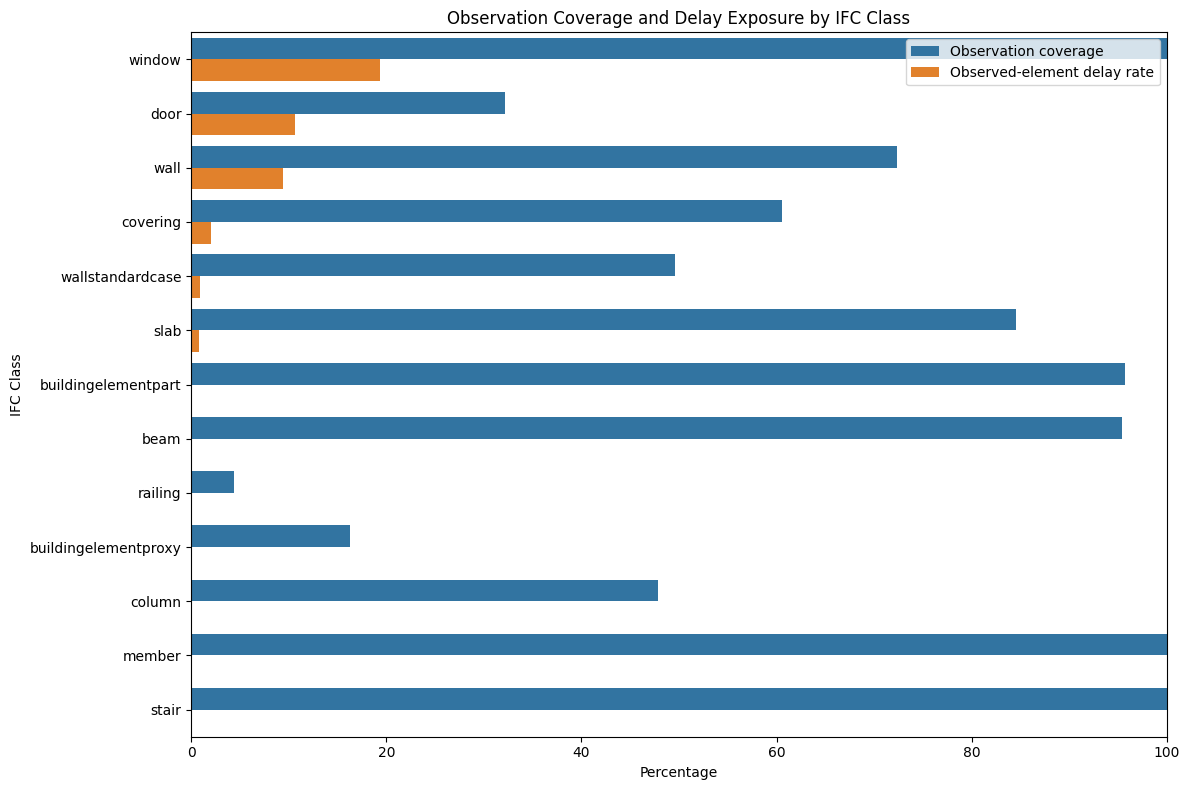

In [14]:
plot_data = class_coverage[
    [
        "Canonical_IfcClass",
        "Observation_Coverage_Percent",
        "Observed_Element_Delay_Rate"
    ]
].copy()

plot_data = plot_data.sort_values(
    "Observed_Element_Delay_Rate",
    ascending=False
)

plot_long = plot_data.melt(
    id_vars="Canonical_IfcClass",
    value_vars=[
        "Observation_Coverage_Percent",
        "Observed_Element_Delay_Rate"
    ],
    var_name="Metric",
    value_name="Percent"
)

plot_long["Metric"] = plot_long["Metric"].replace({
    "Observation_Coverage_Percent":
        "Observation coverage",
    "Observed_Element_Delay_Rate":
        "Observed-element delay rate"
})

plt.figure(figsize=(12, 8))

sns.barplot(
    data=plot_long,
    y="Canonical_IfcClass",
    x="Percent",
    hue="Metric"
)

plt.title(
    "Observation Coverage and Delay Exposure by IFC Class"
)
plt.xlabel("Percentage")
plt.ylabel("IFC Class")
plt.xlim(0, 100)
plt.legend(title="")
plt.tight_layout()

plt.savefig(
    "class_coverage_and_delay_rate.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [15]:
from google.colab import files

files.download(
    "class_coverage_and_delay_rate.png"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [16]:
display(delay_frequency_summary)
display(task_overlap)

,Number_of_Delayed_Tasks,BIM_Elements
0,1,44
1,2,75


,Task_A,Task_B,Shared_Delayed_Elements
1,ST00950,ST00980,50
2,ST01060,ST01070,13
3,ST01060,ST01000,10
0,ST00510,ST01130,2


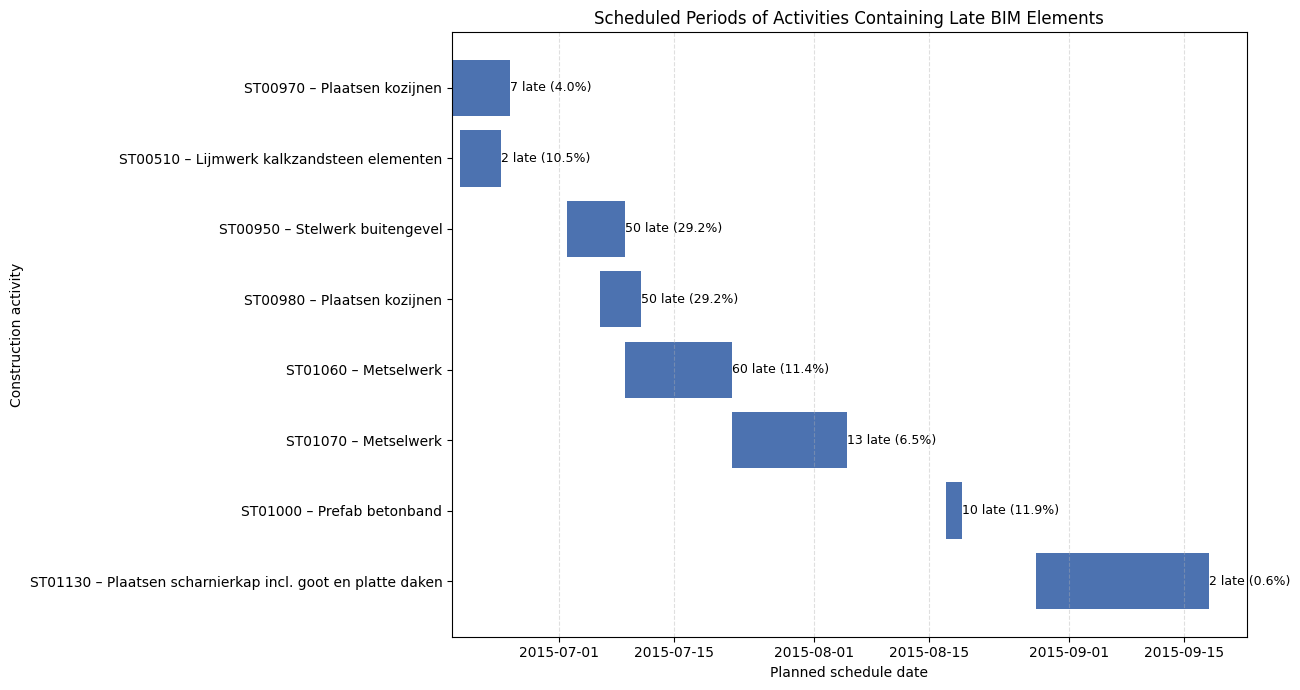

In [17]:
delayed_tasks_timeline = task_performance[
    task_performance["Late_Records"] > 0
].copy()

delayed_tasks_timeline = delayed_tasks_timeline.sort_values(
    "Planned_Start"
)

delayed_tasks_timeline["Task_Label"] = (
    delayed_tasks_timeline["TaskID"]
    + " – "
    + delayed_tasks_timeline["TaskName"]
)

delayed_tasks_timeline["Duration"] = (
    delayed_tasks_timeline["Planned_Finish"]
    - delayed_tasks_timeline["Planned_Start"]
).dt.days + 1

fig, ax = plt.subplots(figsize=(13, 7))

ax.barh(
    delayed_tasks_timeline["Task_Label"],
    delayed_tasks_timeline["Duration"],
    left=delayed_tasks_timeline["Planned_Start"],
    color="#4C72B0"
)

for _, row in delayed_tasks_timeline.iterrows():
    ax.text(
        row["Planned_Finish"] + pd.Timedelta(days=1),
        row["Task_Label"],
        (
            f'{row["Late_Records"]} late '
            f'({row["Late_Rate_Percent"]:.1f}%)'
        ),
        va="center",
        fontsize=9
    )

ax.set_title(
    "Scheduled Periods of Activities Containing Late BIM Elements"
)
ax.set_xlabel("Planned schedule date")
ax.set_ylabel("Construction activity")
ax.invert_yaxis()
ax.grid(axis="x", linestyle="--", alpha=0.4)

plt.tight_layout()

plt.savefig(
    "delayed_activity_timeline.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [18]:
files.download("delayed_activity_timeline.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [19]:
overall_metrics.to_csv(
    "overall_metrics.csv",
    index=False
)

task_performance.to_csv(
    "task_performance.csv",
    index=False
)

class_performance.to_csv(
    "class_performance.csv",
    index=False
)

class_coverage.to_csv(
    "class_coverage.csv",
    index=False
)

element_delay_frequency.to_csv(
    "delayed_element_frequency.csv",
    index=False
)

task_overlap.to_csv(
    "delayed_task_overlap.csv",
    index=False
)

delayed_tasks_timeline.to_csv(
    "delayed_activity_timeline_data.csv",
    index=False
)

In [20]:
output_files = [
    "overall_metrics.csv",
    "task_performance.csv",
    "class_performance.csv",
    "class_coverage.csv",
    "delayed_element_frequency.csv",
    "delayed_task_overlap.csv",
    "delayed_activity_timeline_data.csv"
]

for output_file in output_files:
    files.download(output_file)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>